In [3]:
import pandas as pd

df = pd.read_csv("data.csv", encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
df['CustomerID'].isnull().sum()

np.int64(135080)

In [10]:
df = df.dropna(subset=["CustomerID"])

In [11]:
df['CustomerID'].isnull().sum()

np.int64(0)

In [12]:
df = df[~df["InvoiceNo"].astype(str).str.startswith('C')]

In [13]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [15]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int)

In [16]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [17]:
df["Country"].value_counts().head(10)

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

In [18]:
df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

CustomerID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
12415    124914.53
14156    117379.63
17511     91062.38
16029     81024.84
12346     77183.60
Name: TotalPrice, dtype: float64

In [19]:
df.head(
    
)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [21]:
df["Description"].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1723
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1396
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
Name: count, dtype: int64

In [20]:
df['StockCode'].value_counts().sort_values(ascending=False).head(4)

StockCode
85123A    2035
22423     1723
85099B    1618
84879     1408
Name: count, dtype: int64

In [ ]:
df.set_index("InvoiceDate")["TotalPrice"].resample("ME").sum()

InvoiceDate
2010-12-31     572713.890
2011-01-31     569445.040
2011-02-28     447137.350
2011-03-31     595500.760
2011-04-30     469200.361
2011-05-31     678594.560
2011-06-30     661213.690
2011-07-31     600091.011
2011-08-31     645343.900
2011-09-30     952838.382
2011-10-31    1039318.790
2011-11-30    1161817.380
2011-12-31     518192.790
Freq: ME, Name: TotalPrice, dtype: float64

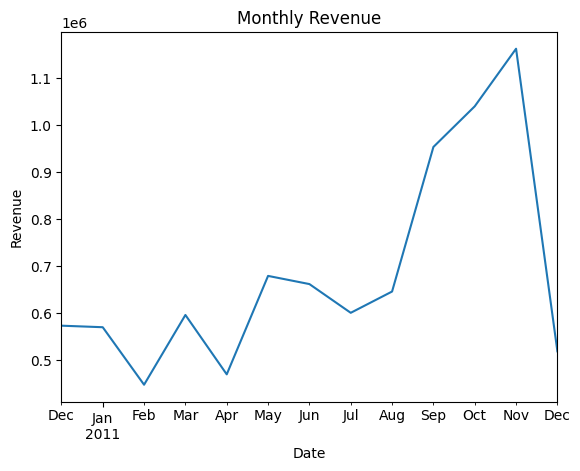

In [ ]:
import matplotlib.pyplot as plt
monthly_sales = df.set_index("InvoiceDate")["TotalPrice"].resample("ME").sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [26]:
monthly_sales

InvoiceDate
2010-12-31     572713.890
2011-01-31     569445.040
2011-02-28     447137.350
2011-03-31     595500.760
2011-04-30     469200.361
2011-05-31     678594.560
2011-06-30     661213.690
2011-07-31     600091.011
2011-08-31     645343.900
2011-09-30     952838.382
2011-10-31    1039318.790
2011-11-30    1161817.380
2011-12-31     518192.790
Freq: ME, Name: TotalPrice, dtype: float64

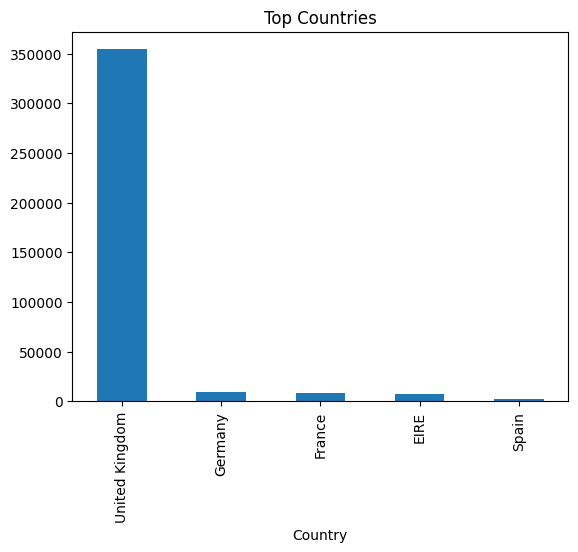

In [27]:
top_countries = df["Country"].value_counts().head(5)

plt.figure()
top_countries.plot(kind="bar")
plt.title("Top Countries")
plt.show()

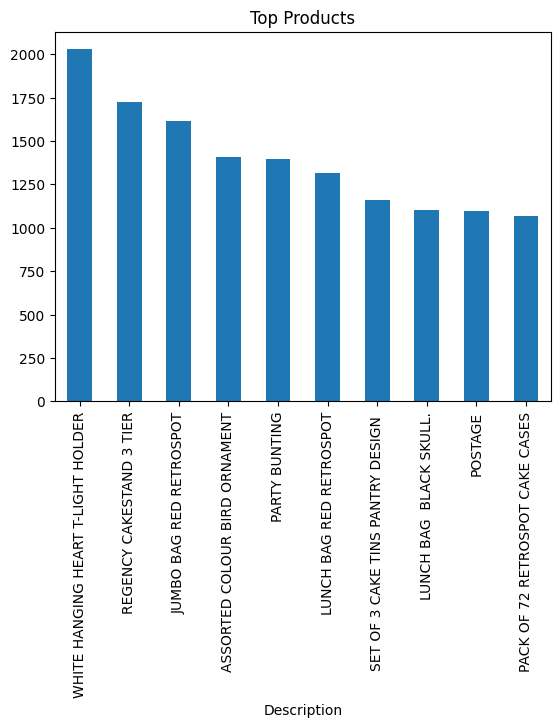

In [28]:
top_products = df["Description"].value_counts().head(10)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top Products")
plt.show()

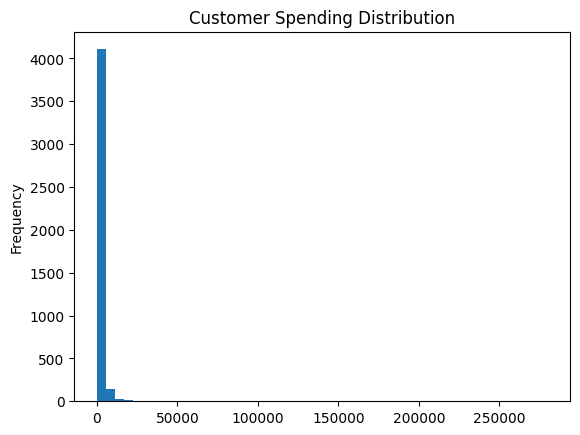

In [29]:
customer_spending = df.groupby("CustomerID")["TotalPrice"].sum()

plt.figure()
customer_spending.plot(kind="hist", bins=50)
plt.title("Customer Spending Distribution")
plt.show()

In [30]:
# phase 2:::::Create RFM Features
# What is RFM again?
# R (Recency) → How recently customer purchased
# F (Frequency) → How often customer purchases
# M (Monetary) → How much money customer spends


In [32]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [33]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

In [35]:
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


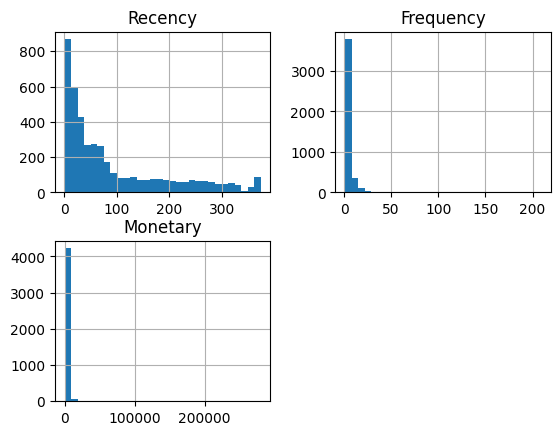

In [38]:
import matplotlib.pyplot as plt

rfm.hist(bins=30)
plt.show()

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [40]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 3, labels=[3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 3, labels=[1,2,3])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 3, labels=[1,2,3])

In [41]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

In [42]:
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,3,5
12347,2,7,4310.00,3,3,3,9
12348,75,4,1797.24,2,2,3,7
12349,19,1,1757.55,3,1,3,7
12350,310,1,334.40,1,1,1,3
...,...,...,...,...,...,...,...
18280,278,1,180.60,1,2,1,4
18281,181,1,80.82,1,2,1,4
18282,8,2,178.05,3,2,1,6


In [43]:
def segment(x):
    if x >= 8:
        return "High Value"
    elif x >= 5:
        return "Medium Value"
    else:
        return "Low Value"

rfm["Segment"] = rfm["RFM_score"].apply(segment)

In [44]:
rfm["Segment"].value_counts()

Segment
Medium Value    1815
High Value      1281
Low Value       1242
Name: count, dtype: int64

In [45]:
X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Segment"]

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

params = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"]
}

grid=GridSearchCV(LogisticRegression(max_iter=1000,class_weight='balanced'),params,cv=5)
grid.fit(X_train_scaled, y_train)

print(grid.best_params_)


c:\Users\malik\Desktop\ML_Revise\.myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\malik\Desktop\ML_Revise\.myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\malik\Desktop\ML_Revise\.myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 

{'C': 10, 'penalty': 'l2'}


In [66]:
y_pred = grid.predict(X_test_scaled)
y_prob = grid.predict_proba(X_test_scaled)

In [67]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8905529953917051


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  High Value       0.91      0.89      0.90       256
   Low Value       0.92      0.92      0.92       249
Medium Value       0.87      0.88      0.87       363

    accuracy                           0.89       868
   macro avg       0.90      0.90      0.90       868
weighted avg       0.89      0.89      0.89       868



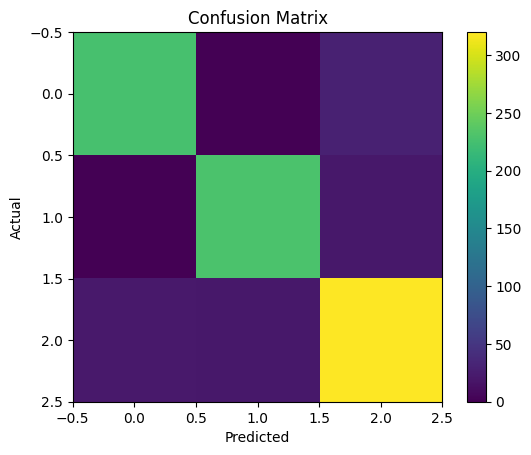

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

             Recency Frequency Monetary
High Value       NaN       NaN      NaN
Low Value        NaN       NaN      NaN
Medium Value     NaN       NaN      NaN


In [64]:
import numpy as np

sample_customer = np.array([[10, 20, 15000]])  # R, F, M
sample_scaled = scaler.transform(sample_customer)

print(grid.predict(sample_scaled))
print(grid.predict_proba(sample_scaled))

['High Value']
[[1.00000000e+00 9.48200771e-56 1.73562319e-11]]


c:\Users\malik\Desktop\ML_Revise\.myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
